**dataset link : https://drive.google.com/file/d/1Po3AI4VyyXHiT9rbCM1AB3xYglymb8Wj/view?usp=sharing**

##**Objective**

the objective is to analyze and predict the flight tickets prices using various factor




In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import warnings

warnings.filterwarnings('ignore')
# to clear some unwanted warining in your output

In [ ]:
df = pd.read_csv('/content/Flight_Booking - Flight_Booking.csv')

In [ ]:
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [ ]:
df = df.drop(columns =['Unnamed: 0'])

In [ ]:
df

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


**Data processing or Eda(exploratory data analysis)**

In [ ]:
df.shape

(300153, 11)

In [ ]:
# information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [ ]:
df.isnull().sum()

,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0
days_left,0


In [ ]:
df.duplicated().sum()

np.int64(531)

In [ ]:
df =df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(299622, 11)

In [ ]:
df.describe()

,duration,days_left,price
count,299622.000000,299622.000000,299622.000000
mean,12.236543,25.997951,20919.793640
std,7.188274,13.560089,22706.397017
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4789.000000
50%,11.250000,26.000000,7426.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


**Data visualization**

In [ ]:
# check the variation in price with different aireline

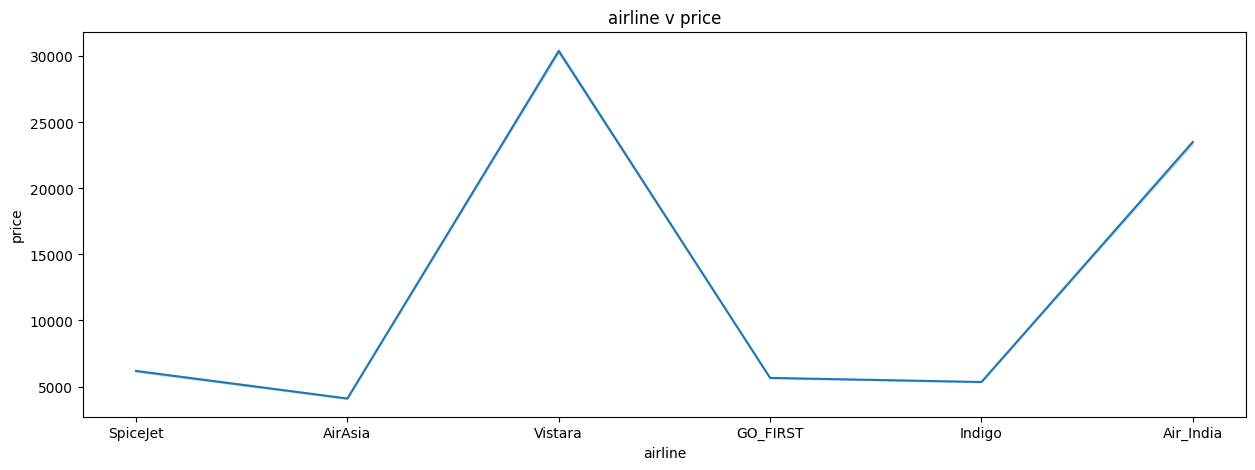

In [ ]:
plt.figure(figsize=(15, 5))
sns.lineplot(x = df['airline'], y =df['price'])
plt.title('airline v price')
plt.show()

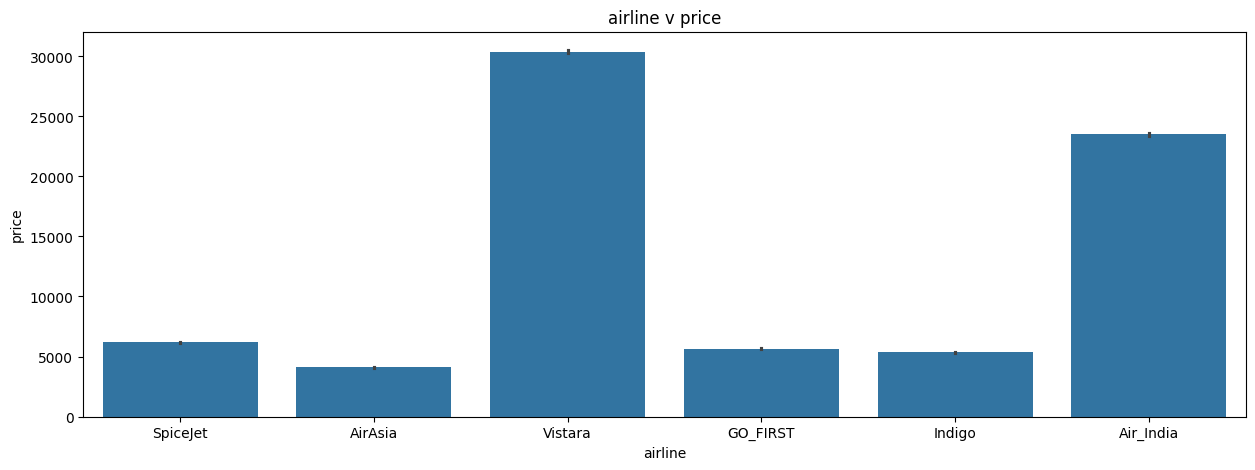

In [ ]:
plt.figure(figsize=(15, 5))
sns.barplot(x = df['airline'], y =df['price'])
plt.title('airline v price')
plt.show()

<Axes: >

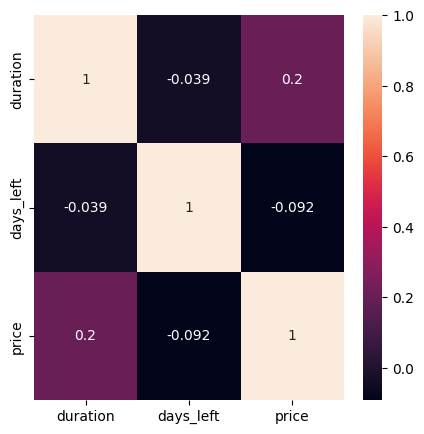

In [ ]:
plt.figure(figsize=(5,5))  # heatmap can only work with numerical data
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True)

# range of prices of all fights of economy and business

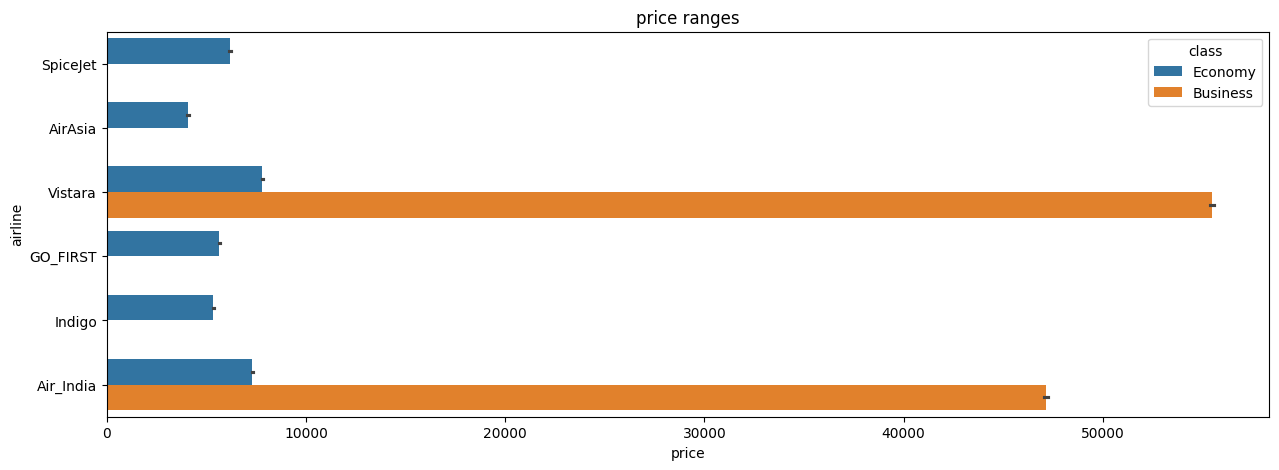

In [ ]:
plt.figure(figsize=(15, 5))
sns.barplot(x ='price', y ='airline',hue ='class', data = df )
plt.title('price ranges')
plt.show()

In [ ]:
print(f"Economy Class Price Range: ${df[df['class'] == 'Economy']['price'].min():.2f} - ${df[df['class'] == 'Economy']['price'].max():.2f}")
print(f"Business Class Price Range: ${df[df['class'] == 'Business']['price'].min():.2f} - ${df[df['class'] == 'Business']['price'].max():.2f}")

Economy Class Price Range: $1105.00 - $42349.00
Business Class Price Range: $12000.00 - $123071.00


In [ ]:
# range of price of flights with source and destination city according to days left

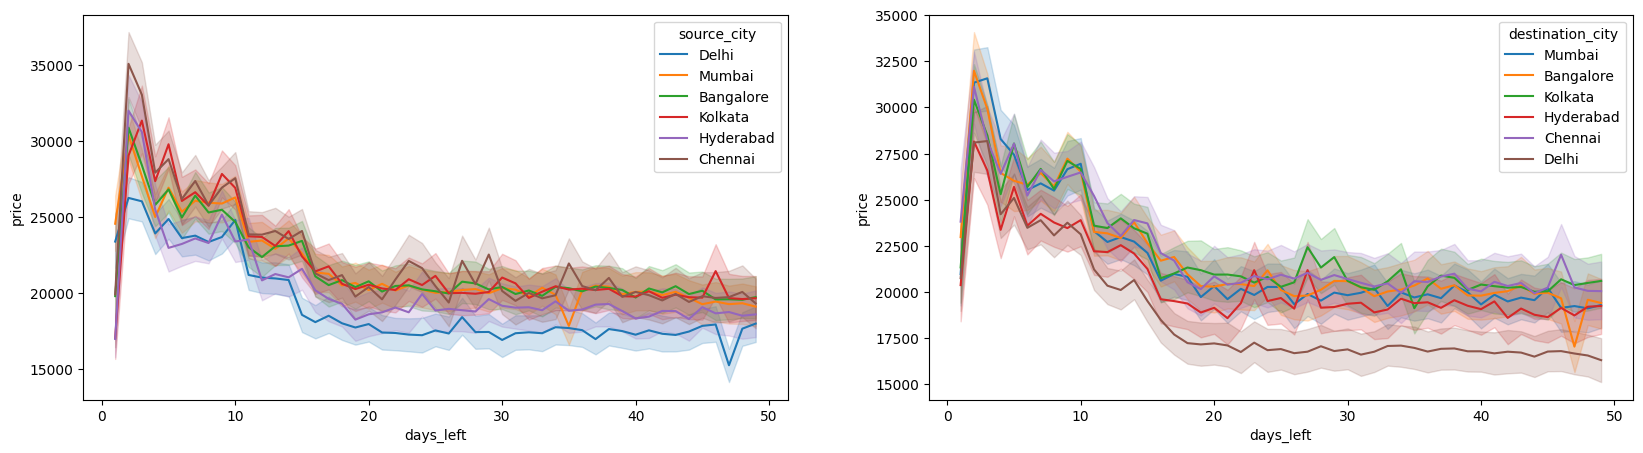

In [ ]:
fig, ax = plt.subplots(1,2, figsize =(20, 5))
sns.lineplot(x ='days_left', y ='price', hue ='source_city', data = df, ax = ax[0])
sns.lineplot(x = 'days_left', y ='price', hue ='destination_city', data = df, ax = ax[1])
plt.show()